In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree



   X  Y  Z Class
0  1  1  1     I
1  1  1  0     I
2  0  0  1    II
3  1  0  0    II

Information Gain:
X = 0.0
Y = 1.0
Z = 0.0

Actual CLasses:
['I', 'I', 'II', 'II']

Predicted Classes:
['I', 'I', 'II', 'II']


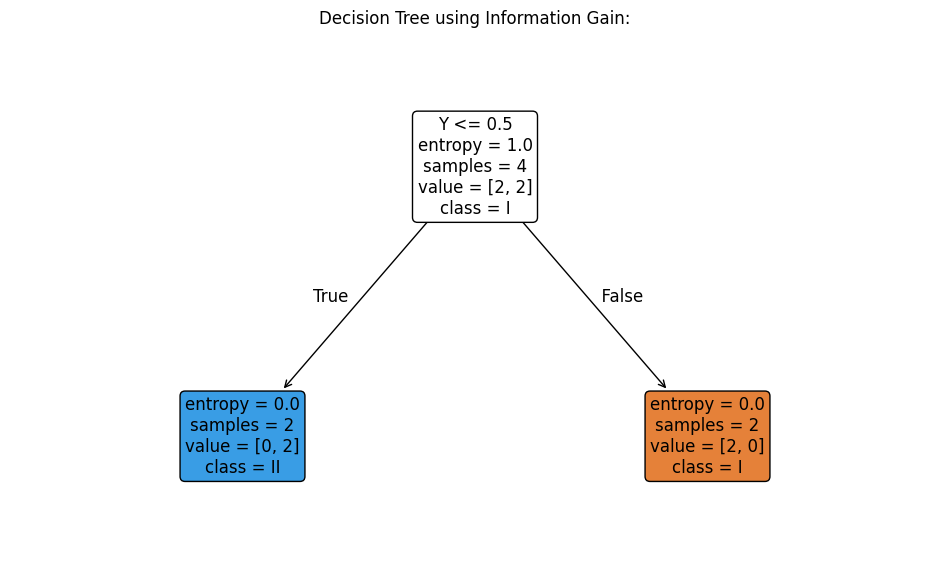

In [19]:
data = {
        'X': [1, 1, 0, 1],
        'Y': [1, 1, 0, 0],
        'Z': [1, 0, 1, 0],
        'Class': ['I', 'I', 'II', 'II']
}

df = pd.DataFrame(data)
print(df)

X = df[['X', 'Y', 'Z']]
y= df[ 'Class' ]

model = DecisionTreeClassifier(
        criterion = 'entropy',
        random_state = 42
)

model.fit(X, y)

print("\nInformation Gain:")

for feature, importance in zip(X.columns, model.feature_importances_):
    print(feature, "=", round(importance, 4))

y_pred=model.predict(X)

print("\nActual CLasses:")
print(list(y))

print("\nPredicted Classes:")
print(list(y_pred))


plt.figure(figsize=(12,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree using Information Gain:")
plt.show()

IRIS DATASET

Dataset Shape:
(150, 6)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Statistical Description:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.82

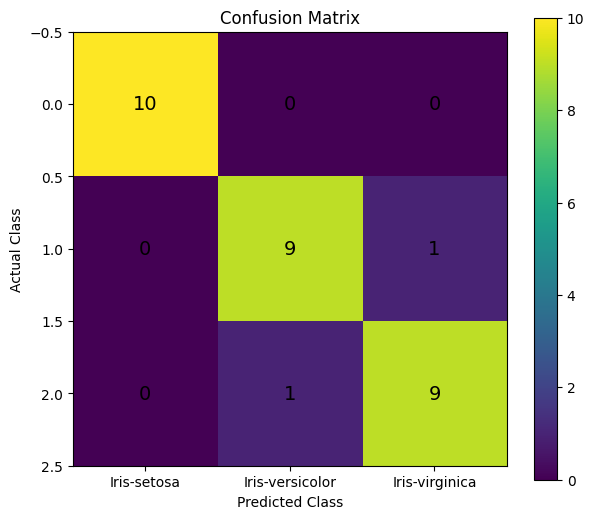


FEATURE IMPORTANCE
SepalLengthCm = 0.0066
SepalWidthCm = 0.0146
PetalLengthCm = 0.672
PetalWidthCm = 0.3068


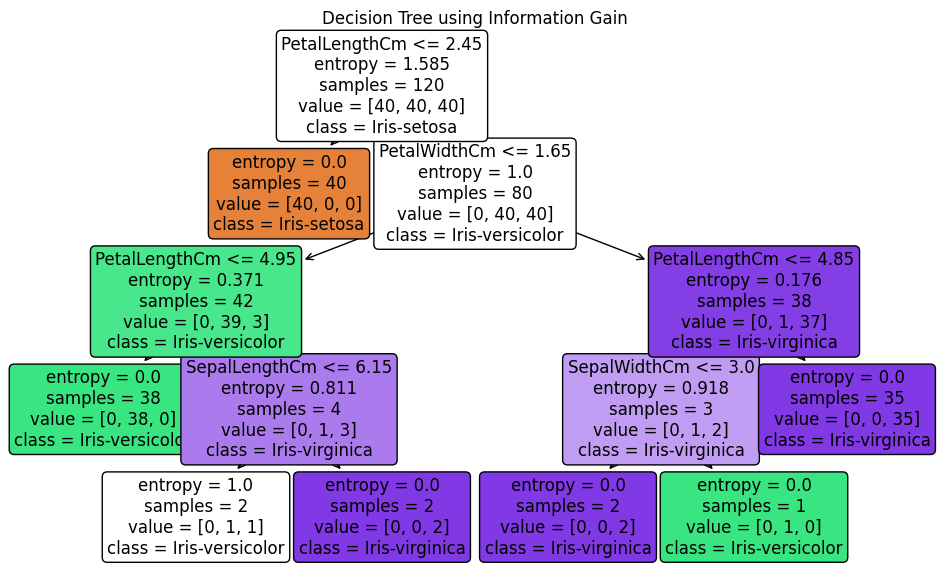

In [20]:
#Iris Flower Classification using Decision Tree
#Dataset: Kaggle Iris Dataset

#import libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

#load kaggle Dataset

path="/kaggle/input/datasets/uciml/iris/Iris.csv"

df=pd.read_csv(path)

print("=" * 60)
print("IRIS DATASET")

print("\nDataset Shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Description:")
print(df.describe())

print("\nClass Distribution:")
print(df["Species"].value_counts())

#Remove ID coloumn

X=df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm",
    ]
]
y=df['Species']

#Split Dataset into Training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:",X_test.shape[0])
model=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

#Train the model

model.fit(X_train,y_train)

print("\nDecision Tree Training Completed!")

#Make Predictions

y_pred=model.predict(X_test)
print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

accuracy=accuracy_score(y_test,y_pred)

print("\n"+"="*60)
print("MODEL ACCURACY")
print("="*60)

print("Accuracy =",round(accuracy*100,2),"%")

#Classification Report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

#Confusion matrix

cm=confusion_matrix(
    y_test,
    y_pred
)
print("\nConfusion Matrix")
print(cm)
plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0,1,2],
    model.classes_
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.show()
print("\n"+"="*60)
print("FEATURE IMPORTANCE")
print("="*60)

for feature,importance in zip(
    X.columns,
    model.feature_importances_
):

    print(
        feature,
        "=",
        round(importance,4)
    )

plt.figure(figsize=(12,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree using Information Gain")
plt.show()